<a href="https://colab.research.google.com/github/mehrabbzz/Computer-Vision-Learning/blob/main/image_data_CNN_reusable_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2️⃣ Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
!pip install split-folders
import splitfolders
import os

In [ ]:
input_folder = "/content/drive/MyDrive/Brain_Cancer"  # contains 3 folders: glioma, meningioma, tumor
output_folder = "/content/input"  # where train/val/test will be created

In [ ]:
# 4️⃣ Split data: 70% train, 20% val, 10% test
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.7, 0.2, 0.1))

Copying files: 6056 files [03:54, 25.82 files/s] 


In [ ]:
# 5️⃣ ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# 6️⃣ Flow from directory
training_set = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    os.path.join(output_folder, 'test'),
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # important for evaluation
)


Found 4237 images belonging to 3 classes.
Found 1209 images belonging to 3 classes.
Found 610 images belonging to 3 classes.


In [ ]:
# 7️⃣ Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes for multiclass classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 8️⃣ Compile model
adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    loss='categorical_crossentropy',  # multiclass
    optimizer=adam,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,151,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,208,003 (84.72 MB)

 Trainable params: 22,208,003 (84.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 9️⃣ Callbacks
checkpoint_path = "/content/CNN_BrainCancer.weights.h5"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1,
                             save_weights_only=True, save_best_only=True, mode='max')

csv_logger = CSVLogger('/content/CNN_BrainCancer.csv', separator=',', append=False)

callbacks_list = [checkpoint, csv_logger]


In [ ]:
# 10️⃣ Train the model
history = model.fit(
    training_set,
    epochs=20,  # can adjust based on performance
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks_list
)

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.5644 - loss: 0.8839
Epoch 1: val_accuracy improved from None to 0.75600, saving model to /content/CNN_BrainCancer.weights.h5

Epoch 1: finished saving model to /content/CNN_BrainCancer.weights.h5
530/530 ━━━━━━━━━━━━━━━━━━━━ 461s 867ms/step - accuracy: 0.6264 - loss: 0.8026 - val_accuracy: 0.7560 - val_loss: 0.6227
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.6803 - loss: 0.7161
Epoch 2: val_accuracy did not improve from 0.75600
530/530 ━━━━━━━━━━━━━━━━━━━━ 499s 861ms/step - accuracy: 0.6955 - loss: 0.6971 - val_accuracy: 0.7039 - val_loss: 0.6712
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7351 - loss: 0.6364
Epoch 3: val_accuracy did not improve from 0.75600
530/530 ━━━━━━━━━━━━━━━━━━━━ 452s 853ms/step - accuracy: 0.7401 - loss: 0.6153 - val_accuracy: 0.7221 - val_loss: 0.6354
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.7471 - loss: 0.5820
Epoch 4

In [ ]:
# 11️⃣ Load best weights
model.load_weights(checkpoint_path)

In [ ]:
# 12️⃣ Evaluate on test set
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - accuracy: 0.9033 - loss: 0.2778
Test Loss: 0.2778
Test Accuracy: 0.9033


77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step


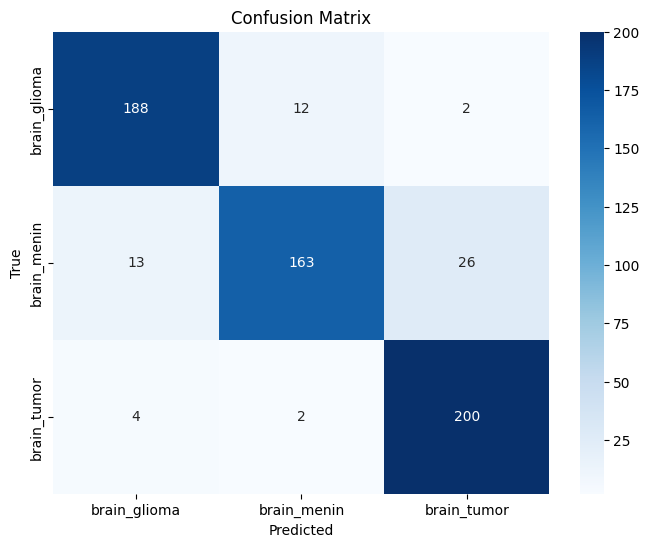

              precision    recall  f1-score   support

brain_glioma       0.92      0.93      0.92       202
 brain_menin       0.92      0.81      0.86       202
 brain_tumor       0.88      0.97      0.92       206

    accuracy                           0.90       610
   macro avg       0.91      0.90      0.90       610
weighted avg       0.90      0.90      0.90       610



In [ ]:

# 13️⃣ Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

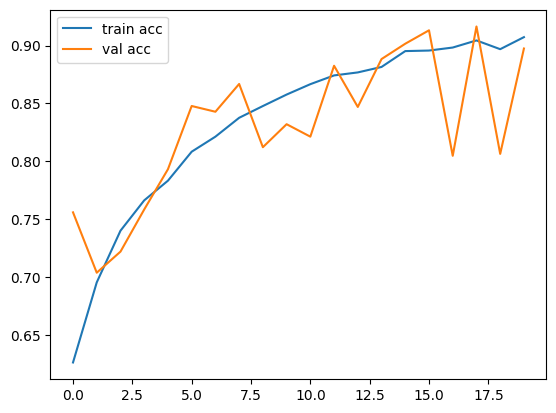

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/CNN_BrainCancer.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.legend()
plt.show()

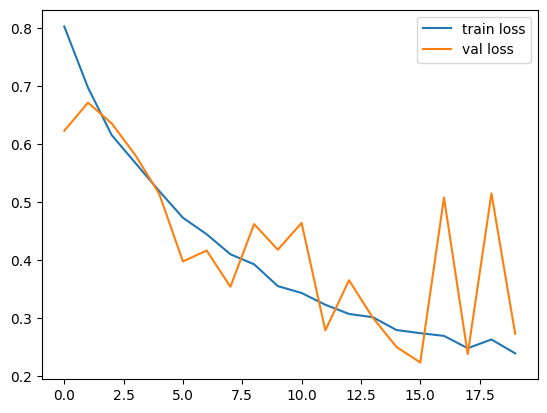

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')
plt.legend()
plt.show()

77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step


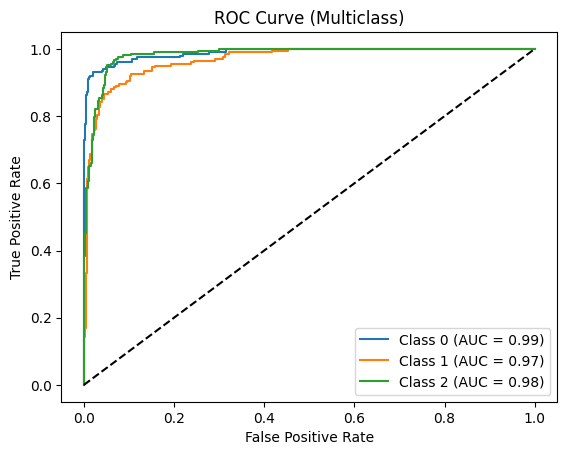

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 3
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass)')
plt.legend()
plt.show()

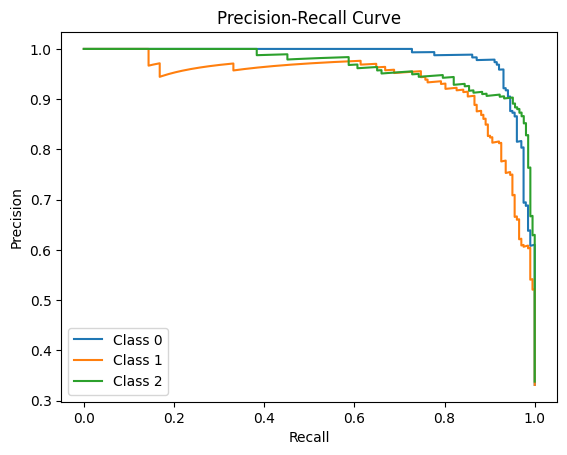

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

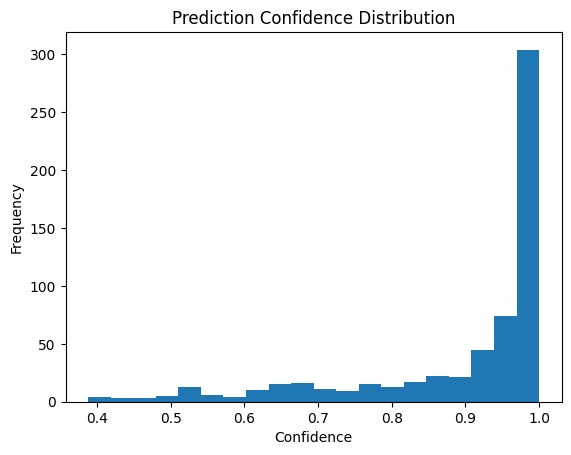

In [ ]:
confidence = np.max(y_pred, axis=1)

plt.figure()
plt.hist(confidence, bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()